# Extracting Spectrograms from Audio

In [1]:
import os
import librosa
import librosa.display
import IPython.display as ipd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
scale_file = "audio/scale.wav"
debussy_file = "audio/debussy.wav"
redhot_file = "audio/redhot.wav"
duke_file = "audio/duke.wav"


In [3]:
ipd.Audio(scale_file)

In [4]:
ipd.Audio(debussy_file)

In [5]:
ipd.Audio(redhot_file)

In [6]:
ipd.Audio(duke_file)

In [7]:
# loading audio using librosa
scale, sr = librosa.load(scale_file)
debussy, _ = librosa.load(debussy_file)
redhot, _ = librosa.load(redhot_file)
duke, _ = librosa.load(duke_file)

## Extracting Short-Time Fourier Transform

In [8]:
FRAME_SIZE = 2048
HOP_SIZE = 512

In [9]:
S_scale = librosa.stft(scale, n_fft=FRAME_SIZE, hop_length=HOP_SIZE)
S_scale.shape

(1025, 342)

In [10]:
type(S_scale[0][0])

numpy.complex64

### Calulating the Spectrograms

In [11]:
Y_scale = np.abs(S_scale) ** 2
Y_scale.shape

(1025, 342)

In [12]:
type(Y_scale[0][0])

numpy.float32

### Visualizing spectrogram

In [13]:
def plot_spectrogram(Y, sr, hop_length, y_axis="linear"):
    plt.figure(figsize=(25,10))
    librosa.display.specshow(
        Y, sr=sr, hop_length=hop_length,
        x_axis="time", 
        y_axis=y_axis
    )
    plt.colorbar(format="%+2.f")

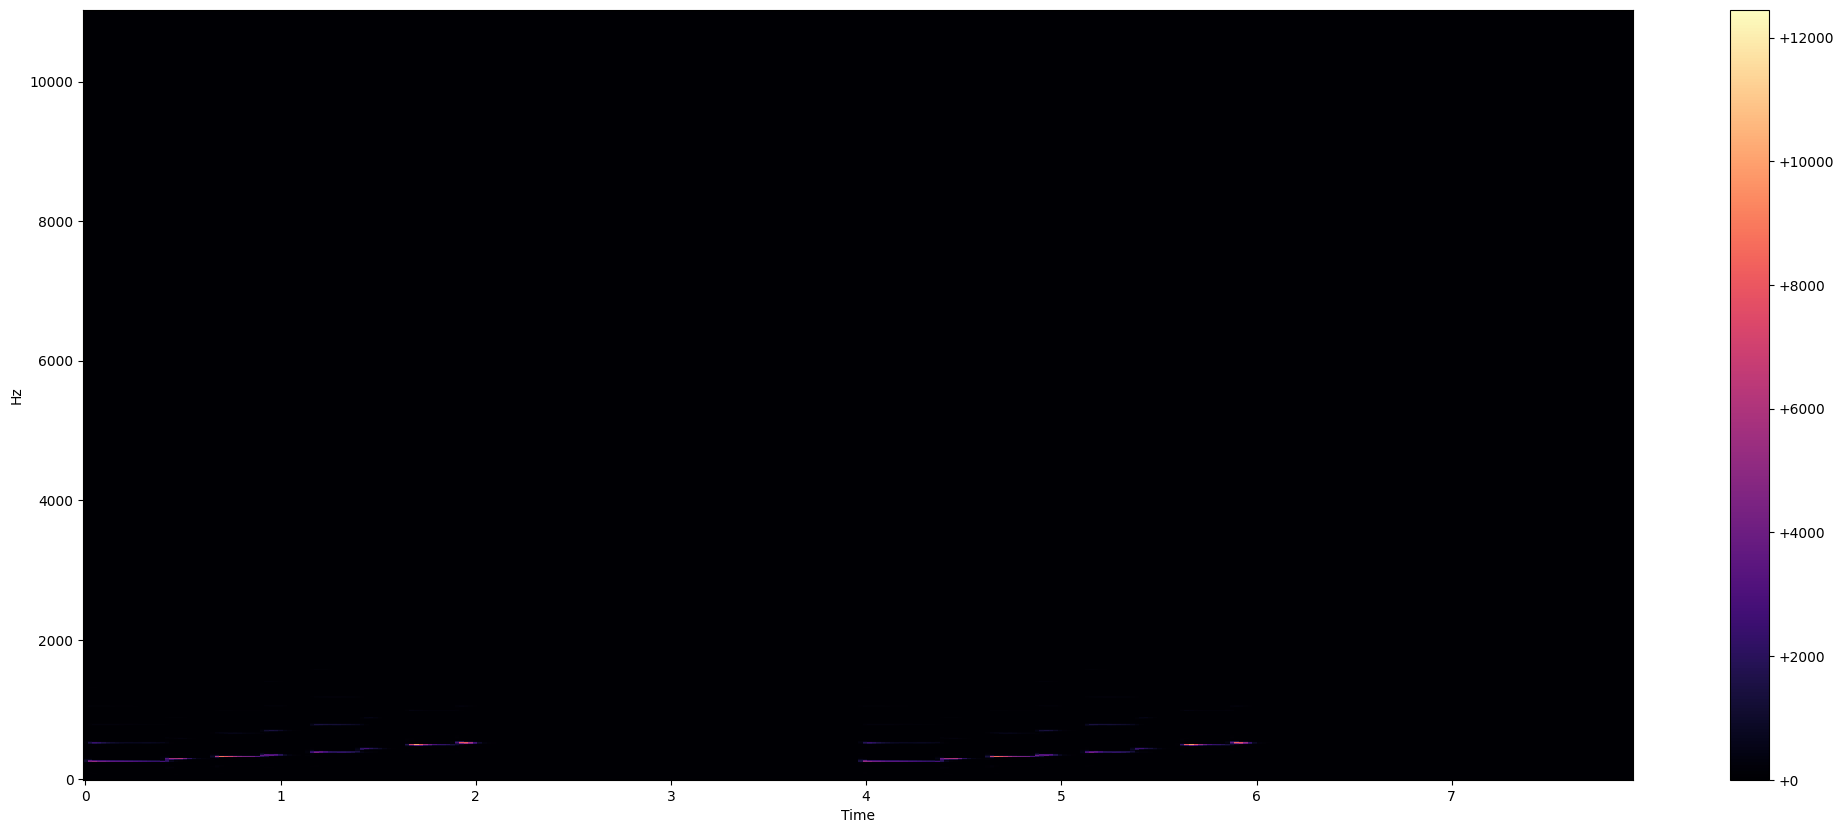

In [14]:
plot_spectrogram(Y_scale, sr, HOP_SIZE)

### Log-Amplitude Spectrogram

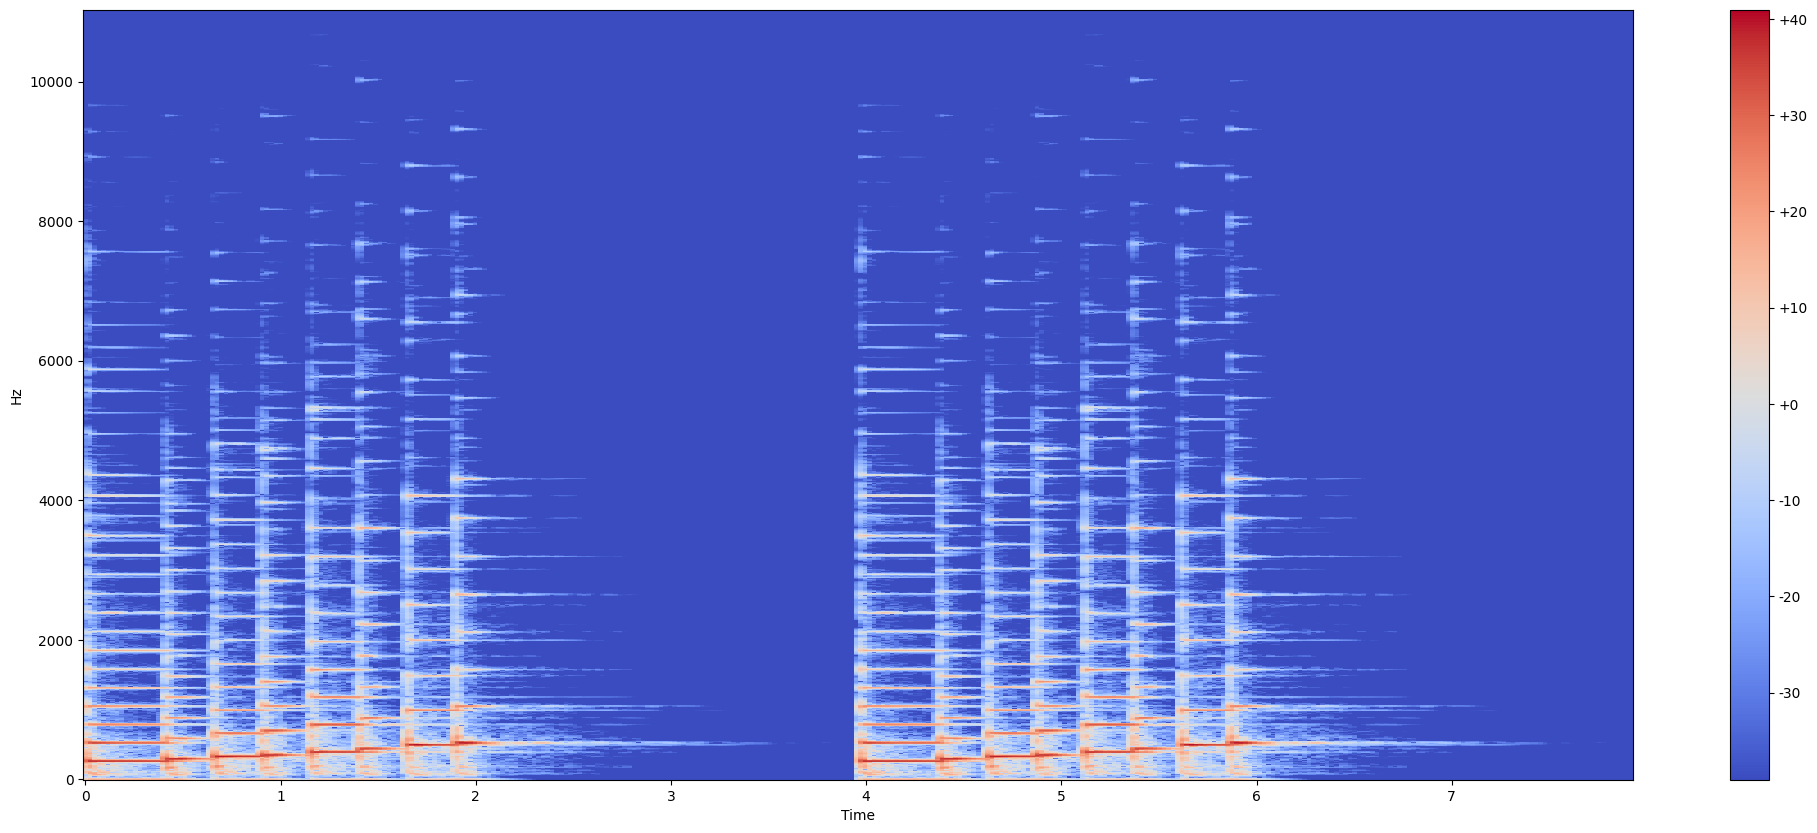

In [15]:
Y_log_scale = librosa.power_to_db(Y_scale)
plot_spectrogram(Y_log_scale, sr, HOP_SIZE)

### Log-Frequency Spectrogram

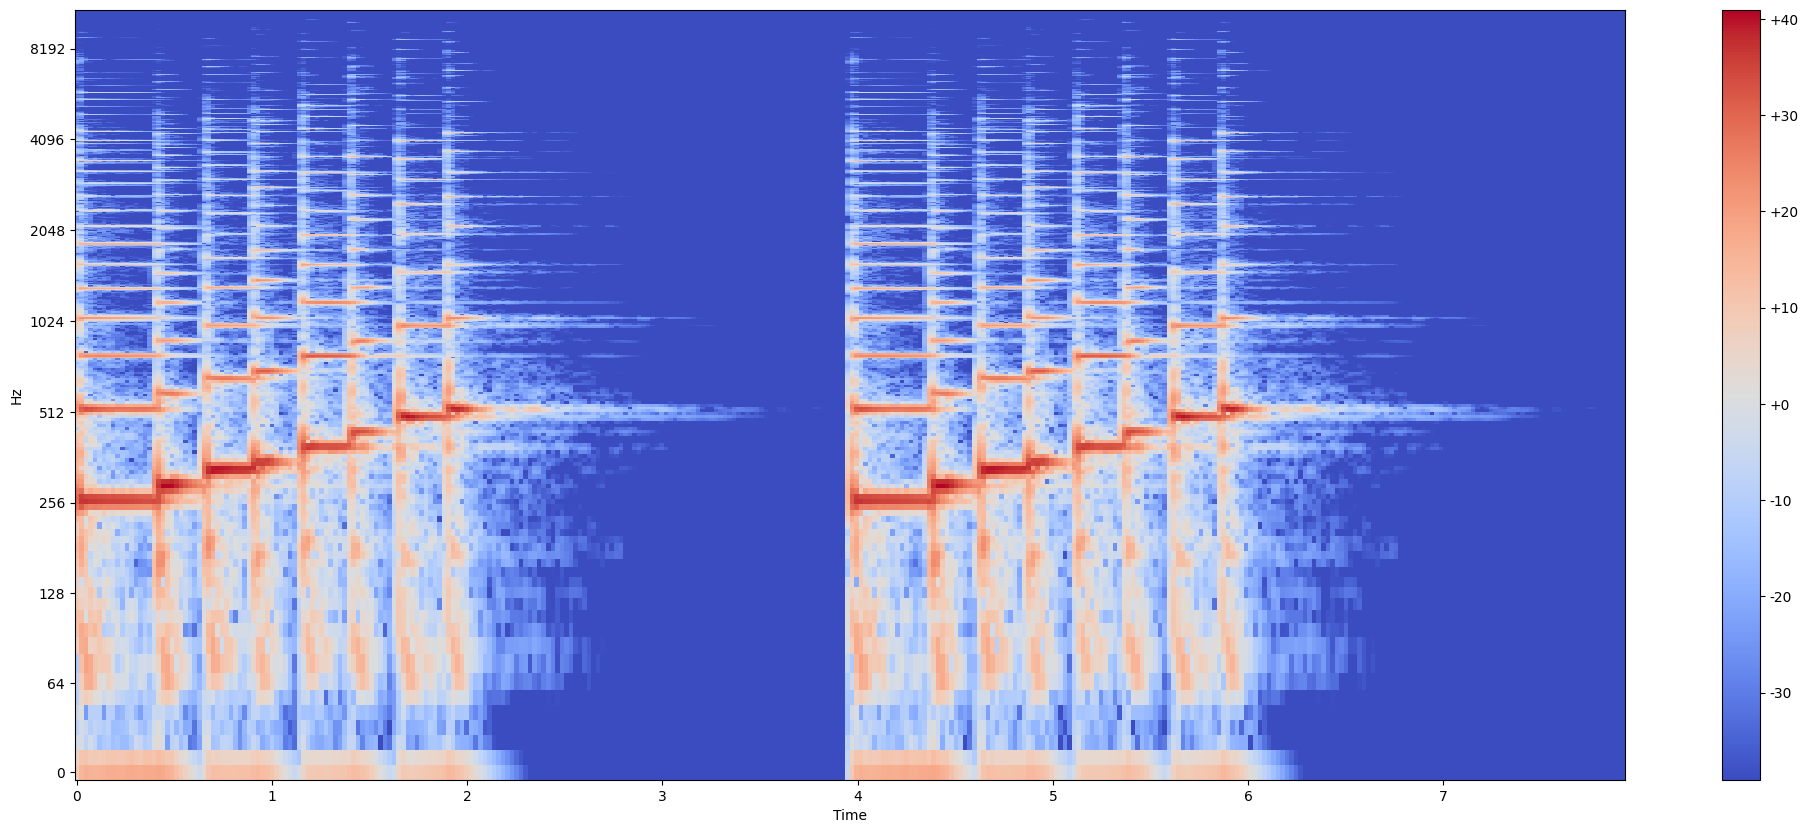

In [16]:
plot_spectrogram(Y_log_scale, sr, HOP_SIZE, y_axis="log")